# **Jason Monroe**

jwmonroe1@gmail.com

Project #5 Plants Seedling Classification  
(Full Code Version)

Computer Vision

jmonroe-proj05-plants-seeding.ipynb


December 10, 2024

# Introduction to Computer Vision: Plant Seedlings Classification

## Problem Statement



### Context

In recent times, the field of agriculture has been in urgent need of modernizing, since the amount of manual work people need to put in to check if plants are growing correctly is still highly extensive. Despite several advances in agricultural technology, people working in the agricultural industry still need to have the ability to sort and recognize different plants and weeds, which takes a lot of time and effort in the long term. The potential is ripe for this trillion-dollar industry to be greatly impacted by technological innovations that cut down on the requirement for manual labor, and this is where Artificial Intelligence can actually benefit the workers in this field, as **the time and energy required to identify plant seedlings will be greatly shortened by the use of AI and Deep Learning.** The ability to do so far more efficiently and even more effectively than experienced manual labor, could lead to better crop yields, the freeing up of human inolvement for higher-order agricultural decision making, and in the long term will result in more sustainable environmental practices in agriculture as well.


### Objective

The aim of this project is to Build a Convolutional Neural Netowrk to classify plant seedlings into their respective categories.

### Data Dictionary

The Aarhus University Signal Processing group, in collaboration with the University of Southern Denmark, has recently released a dataset containing **images of unique plants belonging to 12 different species.**

- The dataset can be download from Olympus.
- The data file names are:
    - images.npy
    - Labels.csv
- Due to the large volume of data, the images were converted to the images.npy file and the labels are also put into Labels.csv, so that you can work on the data/project seamlessly without having to worry about the high data volume.

- The goal of the project is to create a classifier capable of determining a plant's species from an image.

**List of Species**

- Black-grass

1.   List item
2.   List item


- Charlock
- Cleavers
- Common Chickweed
- Common Wheat
- Fat Hen
- Loose Silky-bent
- Maize
- Scentless Mayweed
- Shepherds Purse
- Small-flowered Cranesbill
- Sugar beet

### **Note: Please use GPU runtime on Google Colab to execute the code faster.**

In [676]:
# Fix warnings
import os
os.environ['PATH'] += ':/root/.local/bin'

import warnings
warnings.filterwarnings('ignore')

**Note:** *The code above is to fix warning of libraries that will be declared below.*

## Importing necessary libraries

In [251]:
# Installing the libraries with the specified version.
# uncomment and run the following line if Google Colab is being used
#!pip install tensorflow==2.15.0 scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.3 opencv-python==4.8.0.76 -q --user

# Try this version
!pip install tensorflow==2.17.0 scikit-learn==1.3.1 seaborn==0.13.2 matplotlib==3.8.0 numpy==1.25.2 pandas==2.2.2 opencv-python==4.8.0.76 -q --user

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 601.3/601.3 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 MB 12.8 MB/s eta 0:00:00


In [ ]:
# Installing the libraries with the specified version.
# uncomment and run the following lines if Jupyter Notebook is being used
#!pip install tensorflow==2.13.0 scikit-learn==1.2.2 seaborn==0.11.1 matplotlib==3.3.4 numpy==1.24.3 pandas==1.5.2 opencv-python==4.8.0.76 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [775]:
# Libraries to help with reading and manipulating data and randomly selecting data points
import random
import pandas as pd

# Library for performing numerical computations
import cv2
import numpy as np
import seaborn as sns
import time  # For performance analysis

# Library for creating and showing plots
import matplotlib.pyplot as plt

# Library for reading and showing images
import matplotlib.image as mpimg

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, LabelBinarizer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    recall_score,
    precision_score,
    f1_score,
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    explained_variance_score,
)

import tensorflow as tf
from tensorflow.keras import backend
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import GlobalAveragePooling2D # Import the GlobalAveragePooling2D layer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Changed import path for ImageDataGenerator
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical

# Importing all the required sub-modules from Keras
from keras.models import Sequential, Model
from keras.applications.vgg16 import VGG16
from keras.preprocessing.image import img_to_array, load_img
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout

from google.colab.patches import cv2_imshow

In [501]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


## Loading the dataset

In [503]:
# Uncomment and run the below code if you are using google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [678]:
# Define file paths for labels and images.
dir_path = '/content/drive/MyDrive/Colab Notebooks/utx-gl/projects/proj-05-plants-seeding/'
csv_file = 'Labels.csv'
npy_file = 'images.npy'
csv_path = dir_path + csv_file
npy_path = dir_path + npy_file

# Define labels and images.
labels = pd.read_csv(csv_path)
images = np.load(npy_path)

## Data Overview

### Understand the shape of the dataset

In [776]:
# head
labels.head()

,Label
0,Small-flowered Cranesbill
1,Small-flowered Cranesbill
2,Small-flowered Cranesbill
3,Small-flowered Cranesbill
4,Small-flowered Cranesbill


In [777]:
# tail
labels.tail()

,Label
4745,Loose Silky-bent
4746,Loose Silky-bent
4747,Loose Silky-bent
4748,Loose Silky-bent
4749,Loose Silky-bent


In [778]:
# shape
labels.shape

(4750, 1)

The data file has 4750 rows and 1 column.

In [779]:
# info
labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4750 entries, 0 to 4749
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Label   4750 non-null   object
dtypes: object(1)
memory usage: 37.2+ KB


In [780]:
# describe T
labels.describe().T

,count,unique,top,freq
Label,4750,12,Loose Silky-bent,654


In [781]:
# check for null values
labels.isnull().sum()

,0
Label,0


There is no missing data in the csv file.

In [782]:
# Now analyze npy data
# head
print(images[:1])  # Print the first element

[[[[ 35  52  78]
   [ 36  49  76]
   [ 31  45  69]
   ...
   [ 78  95 114]
   [ 76  93 110]
   [ 80  95 109]]

  [[ 33  46  68]
   [ 37  50  73]
   [ 48  65  83]
   ...
   [ 81  96 113]
   [ 74  89 105]
   [ 83  95 109]]

  [[ 34  50  68]
   [ 35  52  72]
   [ 70  85 101]
   ...
   [ 83  97 112]
   [ 79  94 108]
   [ 79  94 107]]

  ...

  [[ 35  50  69]
   [ 42  57  73]
   [ 42  57  72]
   ...
   [ 60  76  92]
   [ 67  81  97]
   [ 64  77  95]]

  [[ 36  52  67]
   [ 48  63  78]
   [ 41  57  73]
   ...
   [ 44  66  83]
   [ 58  76  91]
   [ 57  74  90]]

  [[ 44  58  70]
   [ 43  57  73]
   [ 40  55  72]
   ...
   [ 41  70  92]
   [ 55  78  97]
   [ 61  79  96]]]]


In [783]:
# Outputs: (batch_size, height, width, channels)
print(labels.shape)
print(f'Total number of labels: {images.shape[0]}')

print(images.shape)
print(f'Total number of images: {images.shape[0]}')

(4750, 1)
Total number of labels: 4750
(4750, 128, 128, 3)
Total number of images: 4750


The shape of the npy row:


*   batch_size: 4750 (row count)
*   height: 128
*   width: 128
*   channels: 3



In [784]:
# Data type
# mean, median, std dev, min, max
print('Mean:', np.mean(images))
print('Median:', np.median(images))
print('Standard Deviation:', np.std(images))
print('Minimum:', np.min(images))
print('Maximum:', np.max(images))

Mean: 70.04363745545504
Median: 67.0
Standard Deviation: 31.996876308515
Minimum: 0
Maximum: 255


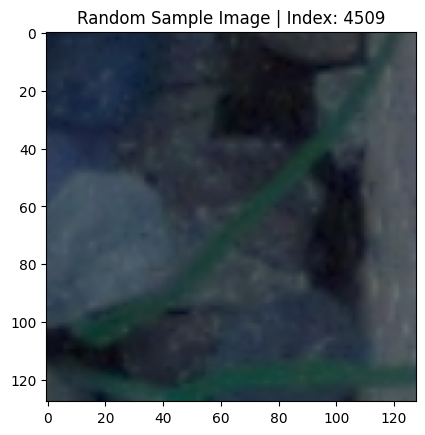

In [785]:
# Randomly sample pixel data
r_index = random.randint(0, len(images))
plt.imshow(images[r_index], cmap='gray')
plt.title(f'Random Sample Image | Index: {r_index}')
plt.show()

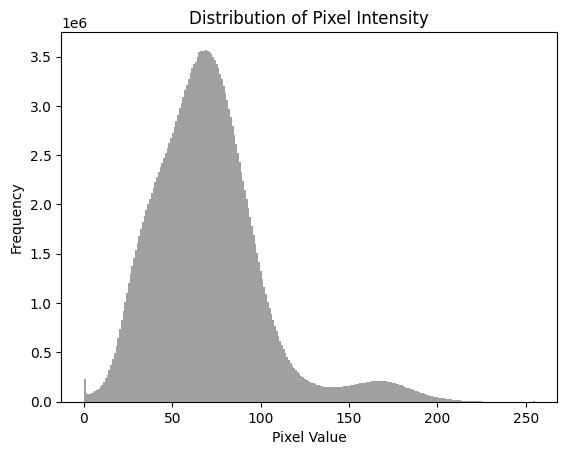

In [786]:
# Plot histogram to check distribution
plt.hist(images.ravel(), bins=256, color='gray', alpha=0.75)
plt.title('Distribution of Pixel Intensity')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.show()

Most of the pixels RGB values are between 50-100 with the peak around 75.  This means most of the image data and value is in the middle.

In [787]:
# Check for NaN values
print(f'There are {np.isnan(images).sum()} NaN values in the dataset.')

There are 0 NaN values in the dataset.


There are no NaN values.

## Define Functions

In [788]:
# Display images
def display_images(images, labels):

  rows = 4
  cols = 4
  num_classes = 10
  categories = np.unique(labels)
  keys = dict(labels['Label'])
  fig = plt.figure(figsize=(10, 8))
  label_cnt = len(labels)

  for i in range(cols):
    for j in range(rows):
      r_index = np.random.randint(1, label_cnt)
      ax = fig.add_subplot(rows, cols, i * rows + j + 1)
      ax.imshow(images[r_index, :])
      ax.set_title(keys[r_index])

  plt.show()

In [789]:
# Encode labels (wrapper function)

# https://www.tensorflow.org/api_docs/python/tf/keras/utils/to_categorical
# Used to one-hot encode integer labels into a binary matrix representation
# that's suitable for classification tasks in deep learing.
def encode_label(var):
  return tf.keras.utils.to_categorical(var, num_classes = 12)

In [790]:
# Evaluate Model and return the accuracy and loss analysis
def evalute_model(model, title, X_test_normalized, y_test_encoded):
  loss, accuracy = model.evaluate(X_test_normalized, y_test_encoded, verbose=2)

  print(f'\n{title} Evaluation')
  print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')

  return loss, accuracy

In [791]:
# Formatting seconds in "Xm Xs Xms" format
import math

def format_duration(seconds):
  mins, secs = divmod(seconds, 60)
  ms = round((secs - math.floor(secs)) * 1000)
  m = round(mins)
  s = math.floor(secs)

  return f'{m}m {s}s {ms}ms'

In [792]:
# Fit Model and return history.  Also time the optimization.
def fit_model(model, title, X_train_normalized, y_train_encoded, X_valid_normalized, y_valid_encoded):

  epoch_cnt = 48
  batch_size = 64

  print(f'\n##################')
  print(f'### {title} ###')
  print(f'##################')
  print('# Fitting model with training and validation data...\n')

  start = time.time()

  history = model.fit(
    X_train_normalized,
    y_train_encoded,
    epochs=epoch_cnt,
    validation_data=(
      X_valid_normalized,
      y_valid_encoded
    ),
    batch_size=batch_size,
    verbose=2,
  )

  end = time.time()
  duration = end - start

  # Print output of how long it took.
  print(f'\n##################')
  print(f'### {title} ###')
  print(f'##################')
  print(f'# Model with "Adam" Optimizer took {format_duration(duration)}.\n')

  return history

In [793]:
# Fit Model with trained generated data
def fit_model_with_generated_data(
    model,
    title,
    X_train_normalized,
    X_valid_normalized,
    y_valid_encoded,
    train_datagen,
    reduce_lr,
    r=42
  ):

  epoch_cnt = 36
  batch_size = 40

  print(f'\n##################')
  print(f'### {title} ###')
  print(f'##################')
  print(f'# Fitting model with augmented training and validation data...\n')


  start = time.time()

  history = model.fit(
    train_datagen.flow(
      X_train_normalized,
      y_train_encoded,
      batch_size=batch_size,
      seed=r,
      shuffle=False
    ),
    epochs=epoch_cnt,
    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
    validation_data=(X_valid_normalized, y_valid_encoded),
    verbose=1,
    callbacks=[reduce_lr]
  )

  end = time.time()
  duration = end - start

  # Print output of how long it took.
  print(f'\n##################')
  print(f'### {title} ###')
  print(f'##################')
  print(f'# Model with "Adam" Optimizer took {format_duration(duration)}.\n')


  return history

In [794]:
# Define labeled barplot.
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count
    n: displays the top n category levels
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()

    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )
        else:
            label = p.get_height()
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )

    plt.show()  # to avoid overlap


In [795]:
# Define a function to compute different metrics to check performance of a classification model built using stats models
def model_performance_classification(model, predictors, target, threshold=0.5):

  """
  Function to compute different metrics to check classification model performance
  model: classifier
  predictors: independent variables
  target: target variable
  threshold: threshold for classification
  """

  # Checking which probabilities are greagter than threshold
  pred = model.predict(predictors) > threshold

  acc = accuracy_score(target, pred)
  prec = precision_score(target, pred, average='weighted')
  rec = recall_score(target, pred, average='weighted')
  f1 = f1_score(target, pred, average='weighted')

  data_perform = pd.DataFrame({'Accuracy': [acc], 'Precision': [prec], 'Recall': [rec], 'F1': [f1]})

  return data_perform

In [796]:
# Normalize the image(s)
def normalize(image):
  MAX_PIXEL_VALUE = 255.0
  return image.astype('float32') / MAX_PIXEL_VALUE

In [797]:
# Define confusion matrix
def plot_confusion_matrix(y_test_encoded, y_pred_test):

  # Obtaining the categorical values from y_test_encoded and y_pred
  y_pred_arg = np.argmax(y_pred_test, axis=1)
  y_test_arg = np.argmax(y_test_encoded, axis=1)

  confusion_matrix = tf.math.confusion_matrix(y_test_arg, y_pred_arg)
  f, ax = plt.subplots(figsize=(10, 8))
  plt.title(f'Confusion Matrix')

  sns.heatmap(
      confusion_matrix,
      annot=True,
      linewidths=0.4,
      fmt='d',
      square=True,
      ax=ax
  )

  plt.show()

In [798]:
# Define plot to determine model history performance
def plot_history(history, title):

  # Plot training and validation accuracy
  plt.figure(figsize=(9, 5))  # Width = 94y, Height = 5
  plt.title(f'{title} (Accuracy)')
  plt.plot(history.history['accuracy'], label='Train Accuracy')
  plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.show()

  print("\n\n")

  # Plot training and validation loss
  plt.figure(figsize=(9, 5))  # Width = 9, Height = 5
  plt.title(f'{title} (Loss)')
  plt.plot(history.history['loss'], label='Train Loss')
  plt.plot(history.history['val_loss'], label='Validation Loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.show()

In [799]:
# Show images from training data
def show_images(train_generator, enc):
  images, labels = next(train_generator)
  fig, axes = plt.subplots(4, 4, figsize=(14, 7))
  fig.set_size_inches(12, 12)

  categories = np.unique(labels)
  keys = dict(enumerate(label_encoder.classes_))

  for (image, label_index, ax) in zip(images, np.argmax(labels, axis=1), axes.flatten()):
    ax.imshow(image)
    ax.set_title(keys[label_index]) # Map numeric label to plant name using keys
    ax.axis('off')

  plt.show()

In [800]:
# Visualizing the predicted and correct label of images from test data
def visualize_prediction(model, enc, X_test, X_test_normalized, y_test_encoded):

  display_img_cnt = 4
  img_cnt = len(X_test_normalized)

  for i in range(0, display_img_cnt):
    r_index = random.randint(0, img_cnt)

    print(f'Random Index:{r_index}\n')

    plt.figure(figsize=(2, 2))
    plt.imshow(X_test[r_index])
    plt.show()

    # Get the predicted probabilities
    predicted_probs = model.predict((X_test_normalized[r_index].reshape(1, 64, 64, 3)))

    # Get the index of the class with the highest probability
    predicted_class_index = np.argmax(predicted_probs, axis=1)

    # Use the index to get the predicted label
    predicted_label = enc.inverse_transform(predicted_class_index)
    print('Predicted Label', predicted_label)

    # Using inverse_transform() to get the output label from the output vector.
    true_label_index = np.argmax(y_test_encoded[r_index])  # Get index of true label
    true_label = enc.classes_[true_label_index]          # Get true label from index
    print('True Label', true_label)

## Exploratory Data Analysis

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you understand the data better.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

1. How are these different category plant images different from each other?
2. Is the dataset provided an imbalance? (Check with using bar plots)

### Images

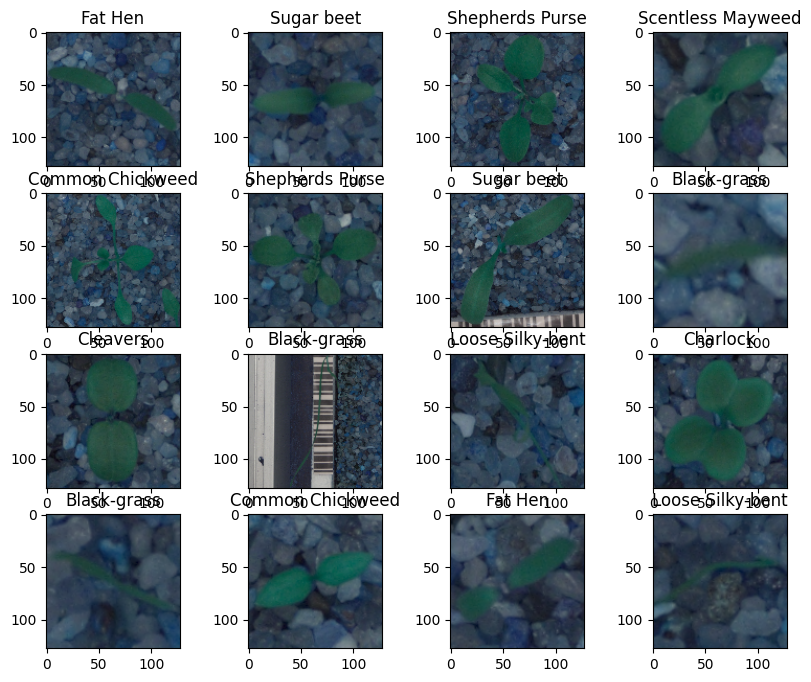

In [804]:
# Plot images like a grid.
display_images(images, labels)

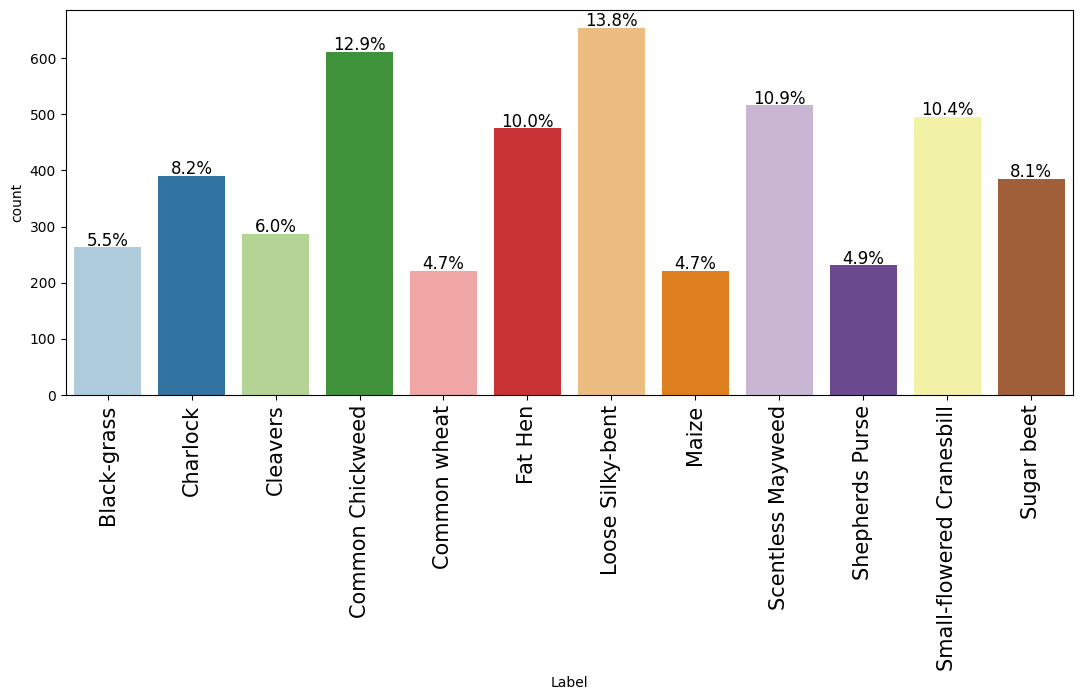

In [805]:
# Label barplot with label
labeled_barplot(labels, 'Label', perc=True)

Observations:
These are the 12 labels of images.  

* Data is not even.  Some labels are less than others meaning there are fewer types of plants in the sample set.
* If all labels were even the average would be 8.3% a piece.  Anything over is over represented.  Anything under is under represented.
* **Charlock** is the closest label to the average.
*   **Loose Silky-Ben** has the most labels with 13.8%.
*   **Maize** and **Common wheat** are tied for last at 4.7%.




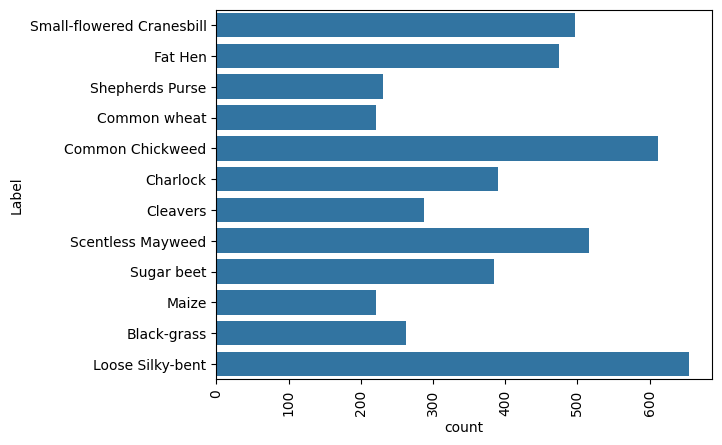

In [806]:
# Check for a data imbalance
sns.countplot(labels['Label'])
plt.xticks(rotation='vertical')
plt.show()

## Data Pre-Processing

### Convert the BGR images to RGB images.

Shape of BGR images: (4750, 128, 128, 3)
Random BGR Image: 3841


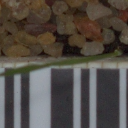

In [807]:
# Convert the BGR images to RGB images.
# First, we will display the image as it is imported which means in BGR format.
bgr_images = []
for image in images:
    bgr_images.append(image)

bgr_images = np.array(bgr_images)

# Now, BGR images contains all images...
print(f'Shape of BGR images: {bgr_images.shape}')

r_index = random.randint(0, len(bgr_images))
print(f'Random BGR Image: {r_index}')
cv2_imshow(bgr_images[r_index]) # Using cv2_imshow to display the image
cv2.waitKey(0)
cv2.destroyAllWindows()

BGR Image

Random RGB Image: 3841



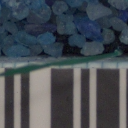

In [808]:
# Now to convert BGR to RGB
rgb_images = []
for image in bgr_images:
    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    rgb_images.append(rgb_image)

# Get image RGB
rgb_images = np.array(rgb_images)

# Using cv2_imshow to display the image.
print(f'Random RGB Image: {r_index}\n')
cv2_imshow(rgb_images[r_index])
cv2.waitKey(0)
cv2.destroyAllWindows()

RGB Image (that has been converted).

### Resize the images

As the size of the images is large, it may be computationally expensive to train on these larger images; therefore, it is preferable to reduce the image size from 128 to 64.

In [809]:
# Resize RGB images
NEW_IMG_SIZE = 64
dims = (NEW_IMG_SIZE, NEW_IMG_SIZE)
resized_images = []

for image in rgb_images:
    resized_image = cv2.resize(image, dims, interpolation=cv2.INTER_LINEAR)
    resized_images.append(resized_image)

Resized Image Below

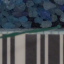

Height: 64, Width: 64
Image resized successfully.


In [810]:
# Using cv2_imshow to display the image
cv2_imshow(resized_images[r_index])
cv2.waitKey(0)
cv2.destroyAllWindows()

# Check if resized worked: Get height, width of image
height, width = resized_images[r_index].shape[:2]
print(f'Height: {height}, Width: {width}')

if height == NEW_IMG_SIZE and width == NEW_IMG_SIZE and height == width:
    print('Image resized successfully.')
else:
    print('Image resizing failed.')

### Data Preparation for Modeling

- Before you proceed to build a model, you need to split the data into train, test, and validation to be able to evaluate the model that you build on the train data
- You'll have to encode categorical features and scale the pixel values.
- You will build a model using the train data and then check its performance

**Split the dataset**

In [811]:
# Split the data into train, test, and validation to be able to evaluate the model
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
r = random.randint(0, 42) # random seeder

X = resized_images
y = labels # labels['Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=r, stratify=labels)

# Then we split the temporary set into train and validation.
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.25, random_state=r, stratify=y_train)

# Convert X_train, X_test to NumPy arrays
X_train = np.array(X_train)
X_test = np.array(X_test)
X_valid = np.array(X_valid)

# Printing the shapes
print(f'Random seeder integer: {r}.')
print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_valid: {X_valid.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_valid: {y_valid.shape}')
print(f'Shape of y_test: {y_test.shape}')

Random seeder integer: 2.
Shape of X_train: (2850, 64, 64, 3)
Shape of X_valid: (950, 64, 64, 3)
Shape of X_test: (950, 64, 64, 3)
Shape of y_train: (2850, 1)
Shape of y_valid: (950, 1)
Shape of y_test: (950, 1)


### Encode the target labels

In [812]:
# Encode categorical features and scale the pixel values
# Creating one-hot encoded representation of target labels
label_encoder = LabelEncoder()

# https://www.tensorflow.org/api_docs/python/tf/keras/utils/to_categorical
# Used to one-hot encode integer labels into a binary matrix representation that's
# suitable for classification tasks in deep learing.
y_train_encoded = encode_label(label_encoder.fit_transform(y_train))
y_test_encoded = encode_label(label_encoder.transform(y_test))
y_valid_encoded = encode_label(label_encoder.transform(y_valid))

### Data Normalization

In [826]:
# Normalizing the image data
X_train_normalized = normalize(X_train)
X_test_normalized = normalize(X_test)
X_valid_normalized = normalize(X_valid)

## Model Building

In [827]:
# Clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [828]:
print('Random seeder integer', r)
np.random.seed(r)
random.seed(r)
tf.random.set_seed(r)

Random seeder integer 2


###CNN Model

In [829]:
# Intializing a sequential CNN model
cnn_model_title = 'Base CNN Model'
cnn_model = Sequential()

# Set input_shape data: height, width, channel (layers of color or intensity information)
input_shape_data = dims + (3,)

# Adding layers to the model
cnn_model.add(Conv2D(128, (3,3), activation='relu', padding = 'same', input_shape=input_shape_data))

# Adding max pooling to reduce the size of output of first conv layer
cnn_model.add(MaxPooling2D((2, 2), padding = 'same'))
cnn_model.add(Conv2D(32, (3, 3), activation='relu', padding="same"))
cnn_model.add(MaxPooling2D((2, 2), padding = 'same'))

cnn_model.add(BatchNormalization())

# Flattening the output of the conv layer after max pooling to make if ready for
# creating dense connection.
cnn_model.add(Flatten())
cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dropout(0.5))

cnn_model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.01)))

# Change the output layer to match the number of classes (12)
cnn_model.add(Dense(12, activation='softmax'))

In [830]:
# Compile Model
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [831]:
# Get Model Summary
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 128)         │           3,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 32)          │          36,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 16, 16, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         524,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 12)                  │             780 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 569,900 (2.17 MB)

 Trainable params: 569,836 (2.17 MB)

 Non-trainable params: 64 (256.00 B)

In [832]:
# Calculate the number of parameters.
param_cnt = cnn_model.count_params()
print(f'Number of parameters: {param_cnt}')

Number of parameters: 569900


In [833]:
# Fit CNN Model and return history.  Also time the optimization.
cnn_history = fit_model(cnn_model, cnn_model_title, X_train_normalized, y_train_encoded, X_valid_normalized, y_valid_encoded)


##################
### Base CNN Model ###
##################
# Fitting model with training and validation data...

Epoch 1/48
45/45 - 6s - 131ms/step - accuracy: 0.2726 - loss: 2.6578 - val_accuracy: 0.1716 - val_loss: 2.8512
Epoch 2/48
45/45 - 2s - 34ms/step - accuracy: 0.4688 - loss: 1.9897 - val_accuracy: 0.2295 - val_loss: 2.6723
Epoch 3/48
45/45 - 1s - 16ms/step - accuracy: 0.5554 - loss: 1.6668 - val_accuracy: 0.3379 - val_loss: 2.4796
Epoch 4/48
45/45 - 1s - 28ms/step - accuracy: 0.6074 - loss: 1.4603 - val_accuracy: 0.4000 - val_loss: 2.3010
Epoch 5/48
45/45 - 1s - 17ms/step - accuracy: 0.6495 - loss: 1.3220 - val_accuracy: 0.5242 - val_loss: 2.1039
Epoch 6/48
45/45 - 1s - 29ms/step - accuracy: 0.6723 - loss: 1.1876 - val_accuracy: 0.5021 - val_loss: 1.9021
Epoch 7/48
45/45 - 1s - 17ms/step - accuracy: 0.6961 - loss: 1.1093 - val_accuracy: 0.5653 - val_loss: 1.6892
Epoch 8/48
45/45 - 1s - 19ms/step - accuracy: 0.7249 - loss: 0.9895 - val_accuracy: 0.6421 - val_loss: 1.4560
Epo

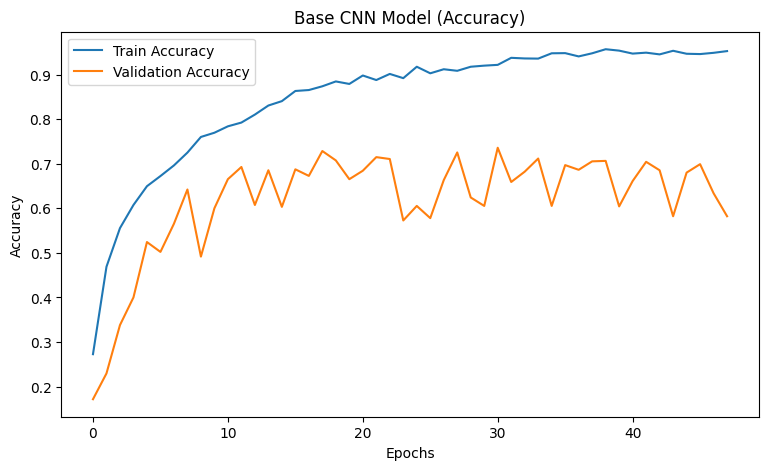

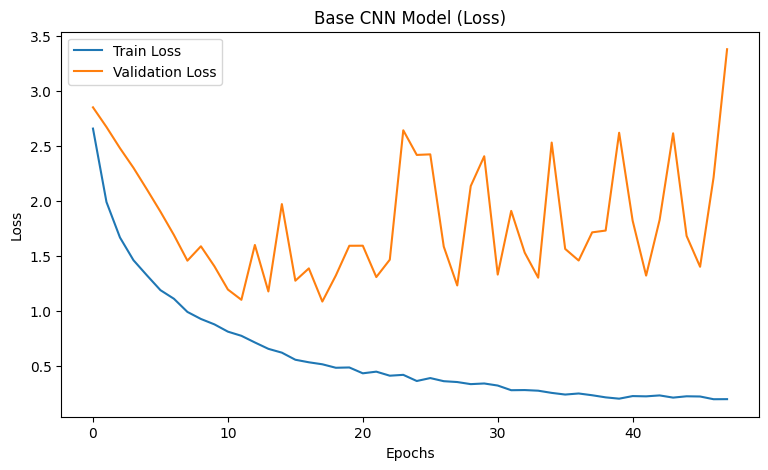

In [840]:
# Plot History
plot_history(cnn_history, cnn_model_title)

Observations


*   Accuracy is higher for training then validation.
* Closest the data comes together is after the 20th epoch.
*   Loss data decreases linearly.
* Validation loss diminishes more extremely than training losses as epochs increase.  In other words it more volatile dealing with the validation loss.



In [835]:
# Evaluate CNN Model
cnn_loss, cnn_accuracy = evalute_model(cnn_model, cnn_model_title, X_test_normalized, y_test_encoded)

30/30 - 1s - 25ms/step - accuracy: 0.5547 - loss: 3.3781

Base CNN Model Evaluation
Test Loss: 3.378058910369873, Test Accuracy: 0.554736852645874


In [841]:
# Get model training performance
cnn_training_perf = model_performance_classification(cnn_model, X_train_normalized, y_train_encoded)
cnn_training_perf

90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Accuracy,Precision,Recall,F1
0,0.797193,0.870908,0.797193,0.790815


In [837]:
# Get prediction data for CNN Model
y_pred_train = cnn_model.predict(X_train_normalized)
y_pred_test = cnn_model.predict(X_test_normalized)
y_test_normal = np.argmax(y_test_encoded, axis=1)

90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


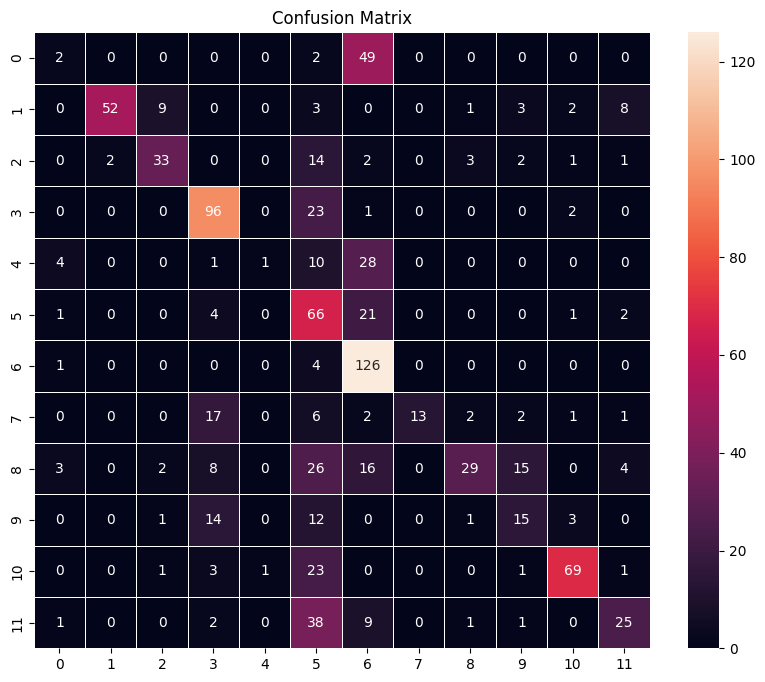

In [838]:
# Plotting confusion matrix
plot_confusion_matrix(y_test_encoded, y_pred_test)

## Model Performance Improvement

**Reducing the Learning Rate:**

**Hint**: Use **ReduceLRonPlateau()** function that will be used to decrease the learning rate by some factor, if the loss is not decreasing for some time. This may start decreasing the loss at a smaller learning rate. There is a possibility that the loss may still not decrease. This may lead to executing the learning rate reduction again in an attempt to achieve a lower loss.

In [726]:
# Define ReduceLRonPlateau()
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.0001, verbose=1)

### **Data Augmentation**

Remember, **data augmentation should not be used in the validation/test data set**.

In [727]:
# Clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [559]:
print('Random seeder integer', r)
np.random.seed(r)
random.seed(r)
tf.random.set_seed(r)

Random seeder integer 6


In [842]:
# Augment the data without using validation or test data.  Only training data.
train_datagen = ImageDataGenerator(
    rotation_range=20,
    fill_mode='nearest',
  #  rescale=1./255,
)

# Flowing training images in batches of 48 using train_datagen generator
train_generator = train_datagen.flow(
  X_train_normalized,
  y_train_encoded,
  batch_size=48
)

### CNN Model with Data Augmentation

In [843]:
# Init model #2 with augmented data
# CNN Model with Data Augmentation or Data Augmented CNN Model
dat_augm_model_title = 'CNN Model with Data Augmentation'

dat_augm_model = Sequential()

# Set input_shape data: height, width, channel (layers of color or intensity information)
input_shape_data = dims + (3,)

# Adding layers to the model
dat_augm_model.add(
  Conv2D(64, (3,3), activation='relu', padding = 'same', input_shape=input_shape_data)
)

# Adding max pooling to reduce the size of output of first conv layer
dat_augm_model.add(MaxPooling2D((2, 2), padding = 'same'))
dat_augm_model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
dat_augm_model.add(MaxPooling2D((2, 2), padding = 'same'))
dat_augm_model.add(BatchNormalization())

# Flattening the output of the conv layer after max pooling to make if ready for
# creating dense connection.
dat_augm_model.add(Flatten())
dat_augm_model.add(Dense(16, activation='relu'))
dat_augm_model.add(Dropout(0.5))
#dat_augm_model.add(Dense(16, activation='relu', kernel_regularizer=l2(0.01)))

# Change the output layer to match the number of classes (12)
dat_augm_model.add(Dense(12, activation='softmax')) # Changed from 16 to 12

In [844]:
# Compile Data Augmented CNN Model
dat_augm_model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [845]:
# Generate summary
dat_augm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 64, 64, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 32, 32, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 16, 16, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │         131,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 12)                  │             204 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 151,676 (592.48 KB)

 Trainable params: 151,612 (592.23 KB)

 Non-trainable params: 64 (256.00 B)

In [846]:
# Fit model with augmented data
# r => random seeder
dat_augm_history = fit_model_with_generated_data(
  dat_augm_model,
  dat_augm_model_title,
  X_train_normalized,
  X_valid_normalized,
  y_valid_encoded,
  train_datagen,
  reduce_lr,
  r
)


##################
### CNN Model with Data Augmentation ###
##################
# Fitting model with augmented training and validation data...

Epoch 1/36
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 107ms/step - accuracy: 0.1258 - loss: 2.5131 - val_accuracy: 0.1379 - val_loss: 2.4471 - learning_rate: 0.0010
Epoch 2/36
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1750 - loss: 2.4019 - val_accuracy: 0.1379 - val_loss: 2.4468 - learning_rate: 0.0010
Epoch 3/36
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.2384 - loss: 2.2127 - val_accuracy: 0.1495 - val_loss: 2.3686 - learning_rate: 0.0010
Epoch 4/36
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3250 - loss: 2.0230 - val_accuracy: 0.1411 - val_loss: 2.3952 - learning_rate: 0.0010
Epoch 5/36
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.3502 - loss: 1.9245 - val_accuracy: 0.2663 - val_loss: 2.2271 - learning_rate: 0.0010
Epoch 6/36
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4750 - loss: 1.6902 - val_accuracy: 0

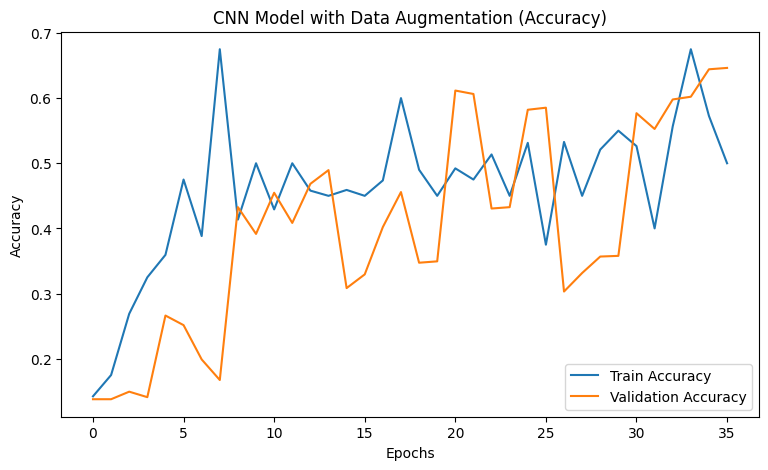

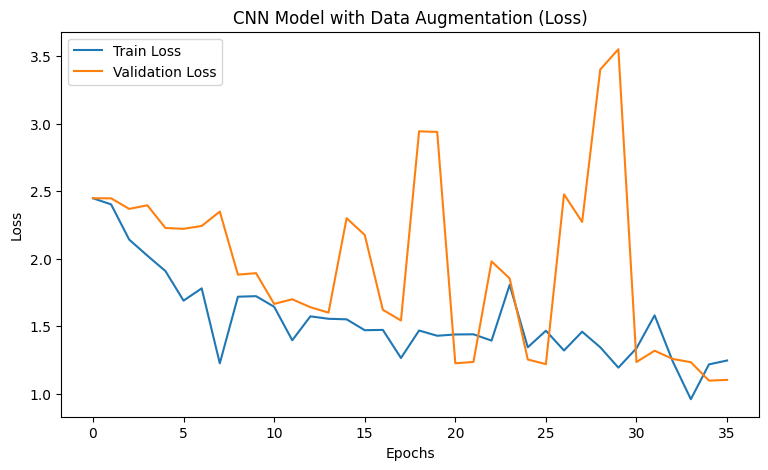

In [847]:
# Look at the images after data has been augmented
plot_history(dat_augm_history, dat_augm_model_title)

Observations


*   The results are unexpected.  The validation accuracy is static until the 5th epochs and then climbs .10% by the 8th epochs and then tepids off.
*   Train accuracy bounces up and down before the accuracy increases while validation accuracy increases.
* Validation accuracy increases as the epochs increase which means it's learning more per epoch. (This is what we want).
* Training accuracy is a hit or miss but eventually goes up after the 25th epoch.  We need better results.
* The losses are closely aligned by each epoch.  The training losses still bounce up and down but overall decreases each epoch.



In [848]:
# Evaluate the CNN Model w/ Data Augmentation
dat_augm_loss, dat_augm_accuracy = evalute_model(dat_augm_model, dat_augm_model_title, X_test_normalized, y_test_encoded)

30/30 - 0s - 3ms/step - accuracy: 0.6284 - loss: 1.1177

CNN Model with Data Augmentation Evaluation
Test Loss: 1.1177259683609009, Test Accuracy: 0.6284210681915283


In [849]:
# Get CNN Model w/ Data Augmentation training performance
dat_augm_model_training_perf = model_performance_classification(dat_augm_model, X_train_normalized, y_train_encoded)
dat_augm_model_training_perf

90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


,Accuracy,Precision,Recall,F1
0,0.482105,0.788007,0.482105,0.536701


In [850]:
# Get prediction data
y_pred_train = dat_augm_model.predict(X_train_normalized)
y_pred_test = dat_augm_model.predict(X_test_normalized)
y_test_normal = np.argmax(y_test_encoded, axis=1)

90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


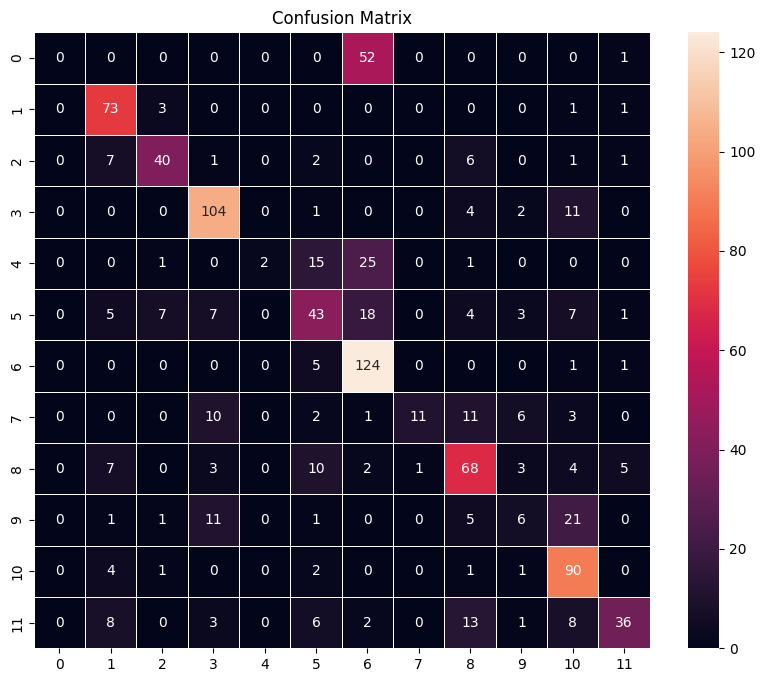

In [851]:
# Show confusion matrix for augmented data
plot_confusion_matrix(y_test_encoded, y_pred_test)

## Final Model

Comment on the final model you have selected and use the same in the below code to visualize the image.

In [852]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [853]:
print('Final Model: Random seeder integer', r)
np.random.seed(r)
random.seed(r)
tf.random.set_seed(r)

Final Model: Random seeder integer 2


VGG Model

In [854]:
# Summary of the whole model
vgg_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape_data)

### Visualizing the prediction

In [855]:
# Create transfer layer
transfer_layer = vgg_model.get_layer('block5_pool')
vgg_model = tf.keras.models.Model(inputs=vgg_model.input, outputs=transfer_layer.output)

In [856]:
# Get visual model summary
vgg_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 64, 64, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 64, 64, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 64, 64, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 32, 32, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 16, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 16, 16, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 16, 16, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 8, 8, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 4, 4, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 2, 2, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [857]:
# Making all the layers of the VGG model non-trainable. i.e. freezing them.
print('Making all layers not trainable...')

for layer in vgg_model.layers:
    layer.trainable = False
    print(f'Name: {layer.name}, Trainable: {layer.trainable}')

Making all layers not trainable...
Name: input_layer, Trainable: False
Name: block1_conv1, Trainable: False
Name: block1_conv2, Trainable: False
Name: block1_pool, Trainable: False
Name: block2_conv1, Trainable: False
Name: block2_conv2, Trainable: False
Name: block2_pool, Trainable: False
Name: block3_conv1, Trainable: False
Name: block3_conv2, Trainable: False
Name: block3_conv3, Trainable: False
Name: block3_pool, Trainable: False
Name: block4_conv1, Trainable: False
Name: block4_conv2, Trainable: False
Name: block4_conv3, Trainable: False
Name: block4_pool, Trainable: False
Name: block5_conv1, Trainable: False
Name: block5_conv2, Trainable: False
Name: block5_conv3, Trainable: False
Name: block5_pool, Trainable: False


### New Model

In [858]:
new_model_title = 'Transfer Learning Model'
new_model = Sequential()

# Adding the convolutional part of the VGG16 model from above
new_model.add(vgg_model) # VGG model w/ Transfer layer

# Flattening the output of the VGG16 model because it is from a convolutional layer
new_model.add(Flatten())

# Adding a dense input layer
new_model.add(Dense(32, activation='relu'))
new_model.add(Dropout(0.3))
new_model.add(Dense(16, activation='relu'))

# Output layer should have 12 nodes for 12 classes and 'softmax' activation
new_model.add(Dense(12, activation='softmax'))

In [859]:
# Compile new model
opt = Adam(learning_rate=0.0001)
new_model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

In [860]:
# Get Summary
new_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ functional (Functional)              │ (None, 2, 2, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │          65,568 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 12)                  │             204 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,780,988 (56.38 MB)

 Trainable params: 66,300 (258.98 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [861]:
# Fit new model and return history
new_model_history = fit_model_with_generated_data(
  new_model,
  new_model_title,
  X_train_normalized,
  X_valid_normalized,
  y_valid_encoded,
  train_datagen,
  reduce_lr,
  r
)


##################
### Transfer Learning Model ###
##################
# Fitting model with augmented training and validation data...

Epoch 1/36
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step - accuracy: 0.1032 - loss: 2.7591 - val_accuracy: 0.1674 - val_loss: 2.4620 - learning_rate: 1.0000e-04
Epoch 2/36
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0500 - loss: 2.5296 - val_accuracy: 0.1653 - val_loss: 2.4612 - learning_rate: 1.0000e-04
Epoch 3/36
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.1365 - loss: 2.4487 - val_accuracy: 0.1853 - val_loss: 2.4153 - learning_rate: 1.0000e-04
Epoch 4/36
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1250 - loss: 2.5548 - val_accuracy: 0.1863 - val_loss: 2.4149 - learning_rate: 1.0000e-04
Epoch 5/36
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.1682 - loss: 2.4111 - val_accuracy: 0.1926 - val_loss: 2.3820 - learning_rate: 1.0000e-04
Epoch 6/36
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1750 - loss: 2.3622 - val

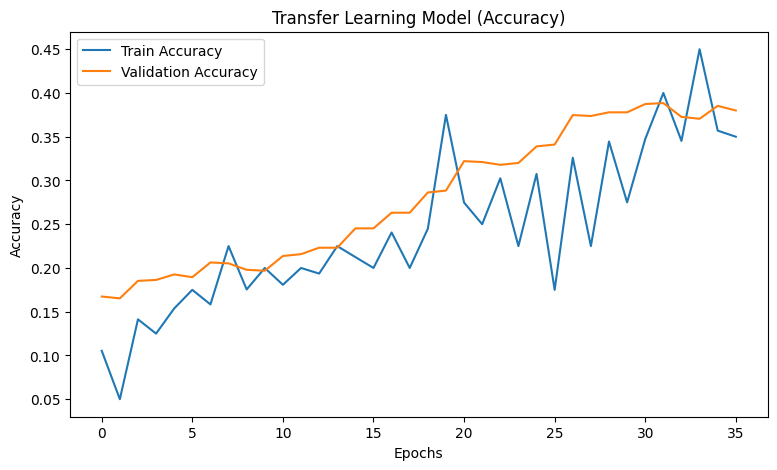

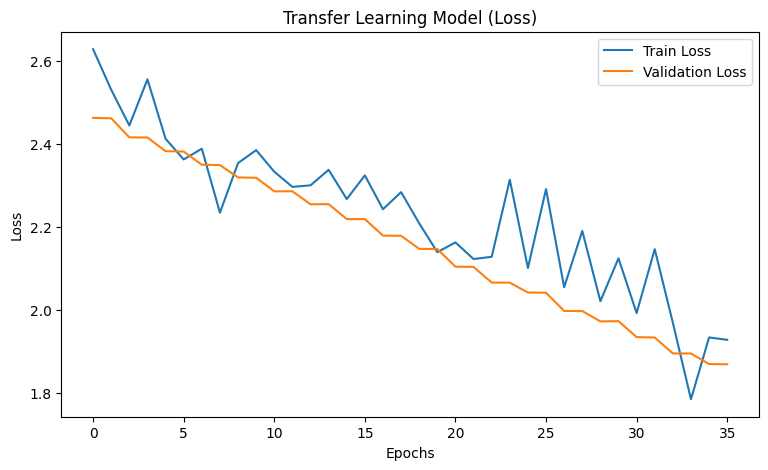

In [862]:
# Plot history
plot_history(new_model_history, new_model_title)

### Observations


1.   For Transfer Learning Model the accuracy for validation increased along with the epochs.
2.   The training accuracy didn't increase too much and actually declined. Not good!
3. The Transfer Learning Model's training loss declined as the epochs increased and the validation losses were more consistent.
4. The model is improving its predictions on the training data by minimizing the error (loss) during backpropagation.
5. The training accuracy is not enough to evaluate the model's performance.



In [863]:
# Evaluate model
new_model_loss, new_model_accuracy = evalute_model(new_model, new_model_title, X_test_normalized, y_test_encoded)

30/30 - 0s - 16ms/step - accuracy: 0.3895 - loss: 1.8972

Transfer Learning Model Evaluation
Test Loss: 1.8972491025924683, Test Accuracy: 0.38947367668151855


In [864]:
# Model performance classification
new_model_training_perf = model_performance_classification(new_model, X_train_normalized, y_train_encoded)
new_model_training_perf

90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


,Accuracy,Precision,Recall,F1
0,0.025965,0.311684,0.025965,0.047163


In [865]:
# Get prediction data for new model
y_pred_train = new_model.predict(X_train_normalized)
y_pred_test = new_model.predict(X_test_normalized)
y_test_normal = np.argmax(y_test_encoded, axis=1)

90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


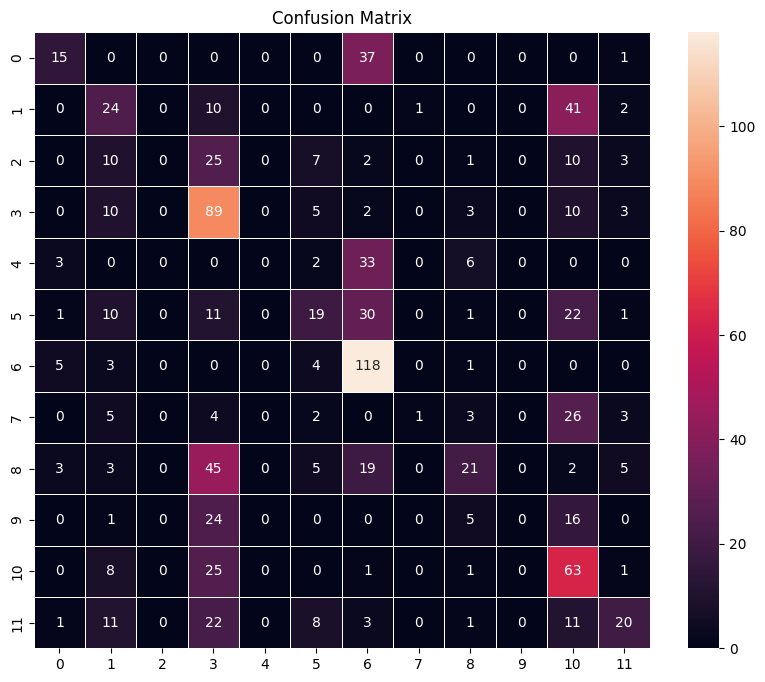

In [866]:
# Plot confusion matrix
plot_confusion_matrix(y_test_encoded, y_pred_test)

Random Index:124



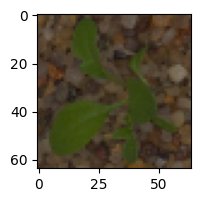

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
Predicted Label ['Common Chickweed']
True Label Shepherds Purse
Random Index:77



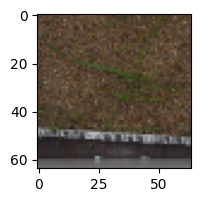

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Predicted Label ['Loose Silky-bent']
True Label Black-grass
Random Index:473



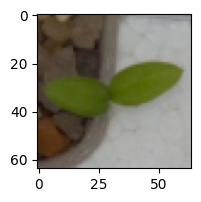

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Predicted Label ['Small-flowered Cranesbill']
True Label Common Chickweed
Random Index:180



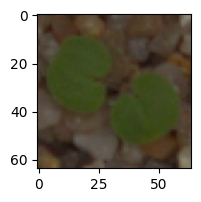

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Predicted Label ['Common Chickweed']
True Label Small-flowered Cranesbill


In [867]:
# Display visualization prediction model
visualize_prediction(new_model, label_encoder, X_test, X_test_normalized, y_test_encoded)

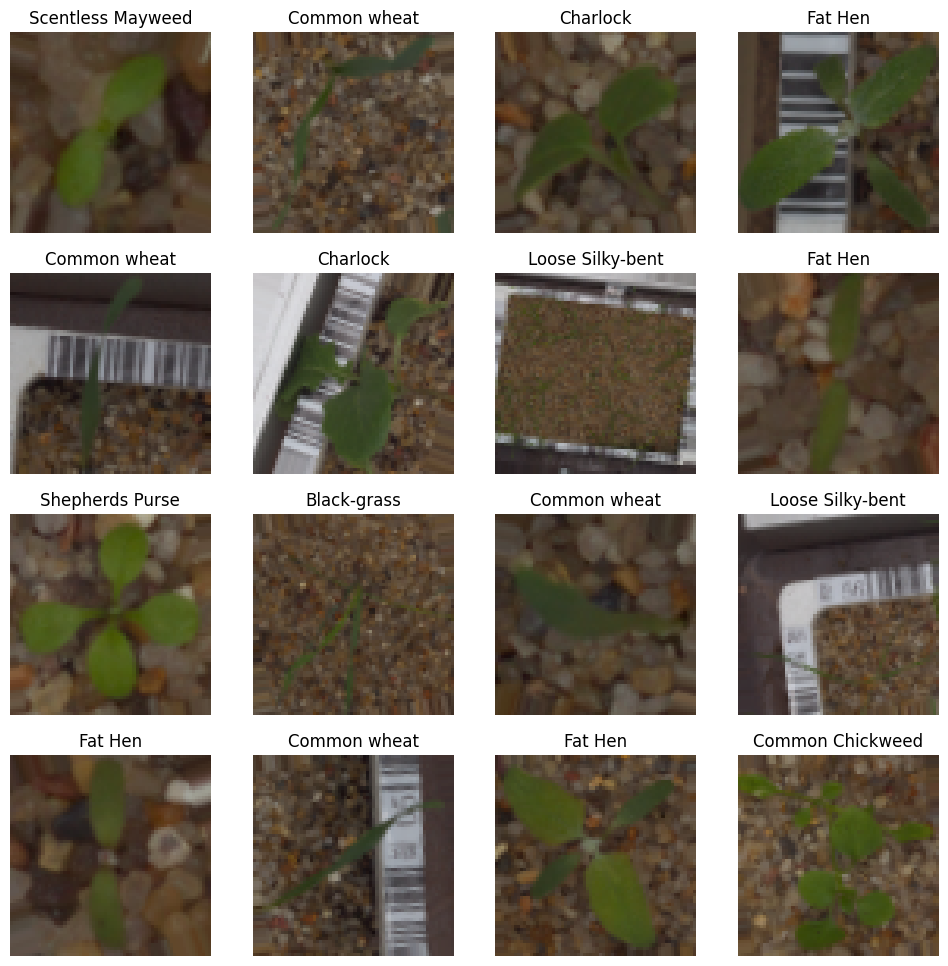

In [868]:
# Show images of manipulated data prior to training
show_images(train_generator, label_encoder)

Conclusions

In [869]:
cnn_training_perf

,Accuracy,Precision,Recall,F1
0,0.797193,0.870908,0.797193,0.790815


In [870]:
dat_augm_model_training_perf

,Accuracy,Precision,Recall,F1
0,0.482105,0.788007,0.482105,0.536701


In [871]:
new_model_training_perf

,Accuracy,Precision,Recall,F1
0,0.025965,0.311684,0.025965,0.047163


In [872]:
# Prepare models for final conclusions

# Build model performance graph.
models = []
models.append(cnn_model_title)
models.append(dat_augm_model_title)
models.append(new_model_title) # New Model

train_accuracy = []
train_accuracy.append(cnn_history.history['accuracy'][-1])
train_accuracy.append(dat_augm_history.history['accuracy'][-1])
train_accuracy.append(new_model_history.history['accuracy'][-1])

validation_accuracy = []
validation_accuracy.append(cnn_history.history['val_accuracy'][-1])
validation_accuracy.append(dat_augm_history.history['val_accuracy'][-1])
validation_accuracy.append(new_model_history.history['val_accuracy'][-1])

test_accuracy = []
test_accuracy.append(cnn_accuracy)
test_accuracy.append(dat_augm_accuracy)
test_accuracy.append(new_model_accuracy)

test_loss = []
test_loss.append(cnn_loss)
test_loss.append(dat_augm_loss)
test_loss.append(new_model_loss)

### Final Results

In [873]:
# Creating matrix to view final data
pd.DataFrame({
    'Models': models,
    'Train Accuracy': train_accuracy,
    'Validation Accuracy': validation_accuracy,
    'Test Accuracy': test_accuracy,
    'Test Loss': test_loss,
})

,Models,Train Accuracy,Validation Accuracy,Test Accuracy,Test Loss
0,Base CNN Model,0.952632,0.582105,0.554737,3.378059
1,CNN Model with Data Augmentation,0.500000,0.646316,0.628421,1.117726
2,Transfer Learning Model,0.350000,0.380000,0.389474,1.897249


## Actionable Insights and Business Recommendations

*   The model correctly identified seedings.
*   The predictor value for each model was high enough to correctly identify which seeding was which.
* Augmenting the data with encoders changed the accuracy and the loss dramatically.
* Transfer Learning helped with the final model in identifying seedings compared to the augmented one.
* Training these models at 64x64 sufficed although 128px would probably be better.
* The size of the filtering helped determine the results.  
* The base CNN model was the best and efficient model to identify the seedings.
* CNN Model accuracy was 95.2%.
* CNN Model with Augmented Data was 50%.
* Transfer Learning Model was at 35%.
* Visualizing the prediction displayed the correct results the majority of the time!
* The Image Data Manipulator was the biggest factor in determining accuracy.
* Have better photos that show plants at various stages of growth.
* Keep backgrounds consistent so that we can focus on the seeding/plants.
* 12 different seedings suffice but wouldn't hurt to have a few more.
* There will be economic benefits with using automation to detect seeding in the future.



_____

# Export File
*Convert ipynb to html in Google Colab*

Upload widget will appear.

In [875]:
# Export File
# @title Convert ipynb to HTML in Colab
# Upload ipynb
from google.colab import files
f = files.upload()

# Convert ipynb to html
import subprocess

file0 = list(f.keys())[0]
_ = subprocess.run(['pip', 'install', 'nbconvert'])
_ = subprocess.run(['jupyter', 'nbconvert', file0, '--to', 'html'])

# download the html
files.download(file0[:-5] + 'html')
print('Exporting: jmonroe-proj-05-plants-seeding.html')

#
# E N D  O F  P R O G R A M
#

Saving jmonroe-proj-05-plants-seeding.ipynb to jmonroe-proj-05-plants-seeding (1).ipynb


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Exporting: jmonroe-proj-05-plants-seeding.html


**End of Program**